In [247]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [248]:
DATA_PATH = "../data/customer_churn_dataset-training-master.csv"
OUTPUT_DIR = "../data_processed"
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2
gap = 5

In [249]:
# load data
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


In [250]:
le = LabelEncoder()
scaler = StandardScaler()

In [251]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [252]:
# encoders = {}
# for col in categorical_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col].astype(str))
#     encoders[col] = le

In [253]:
TEST_SIZE = 0.2
VAL_SIZE = 0.2
gap = 5
n_train = int(len(df) * (1 - TEST_SIZE - VAL_SIZE)) - 2* gap
n_val = int(len(df) * VAL_SIZE)
n_test = len(df) - n_train - n_val + gap
df_train, df_test = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE,)
df_train, df_val = train_test_split(df_train, test_size=VAL_SIZE/(1 - TEST_SIZE), random_state=RANDOM_STATE)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
 

In [254]:
df_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,428529,43,Male,14,18,2,2,Basic,Annual,671.70,18,0
1,167702,56,Male,20,14,9,21,Basic,Monthly,386.00,30,1
2,47429,40,Female,55,22,0,12,Standard,Quarterly,806.00,16,1
3,277216,30,Male,3,27,3,8,Premium,Quarterly,972.35,25,0
4,72537,65,Female,6,4,10,29,Basic,Annual,978.00,25,1


In [255]:
def encode_features(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Encode categorical features using LabelEncoder."""
    df = df.copy()
    encoders = {}

    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

    # Remove target from categorical columns if present
    # if "Churn" in categorical_cols:
    #     categorical_cols.remove("Churn")

    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

    return df, encoders

In [256]:
df_train, train_encoders = encode_features(df_train)
df_val, val_encoders = encode_features(df_val)  
df_test, test_encoders = encode_features(df_test)

In [257]:
df_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,428529,43,1,14,18,2,2,0,0,671.70,18,0
1,167702,56,1,20,14,9,21,0,1,386.00,30,1
2,47429,40,0,55,22,0,12,2,2,806.00,16,1
3,277216,30,1,3,27,3,8,1,2,972.35,25,0
4,72537,65,0,6,4,10,29,0,0,978.00,25,1


In [258]:
X_train, y_train = df_train.drop("Churn", axis=1), df_train["Churn"]
X_val, y_val = df_val.drop("Churn", axis=1), df_val["Churn"]
X_test, y_test = df_test.drop("Churn", axis=1), df_test["Churn"]

In [259]:
X_train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,428529,43,1,14,18,2,2,0,0,671.70,18
1,167702,56,1,20,14,9,21,0,1,386.00,30
2,47429,40,0,55,22,0,12,2,2,806.00,16
3,277216,30,1,3,27,3,8,1,2,972.35,25
4,72537,65,0,6,4,10,29,0,0,978.00,25


In [260]:
def scale_features(X: pd.DataFrame, scaler: StandardScaler = None) -> tuple[pd.DataFrame, StandardScaler]:
    """Scale numerical features using StandardScaler."""
    cols = X.select_dtypes(include=[np.number]).columns.tolist()
    X = X.copy()
    if scaler is None:
        scaler = StandardScaler()
        X[cols] = scaler.fit_transform(X[cols])
    else:
        X[cols] = scaler.transform(X[cols])

    return X, scaler

In [261]:
if 'customerID' in X_train.columns:
    X_train = X_train.drop(columns=["customerID"])
if 'customerID' in df_train.columns:
    df_train = df_train.drop(columns=["customerID"])
if 'customerID' in df_val.columns:
    df_val = df_val.drop(columns=["customerID"])
if 'customerID' in df_test.columns:
    df_test = df_test.drop(columns=["customerID"])

In [262]:
X_train, scaler = scale_features(df_train)
X_val, _ = scale_features(df_val, scaler)
X_test, _ = scale_features(df_test, scaler)

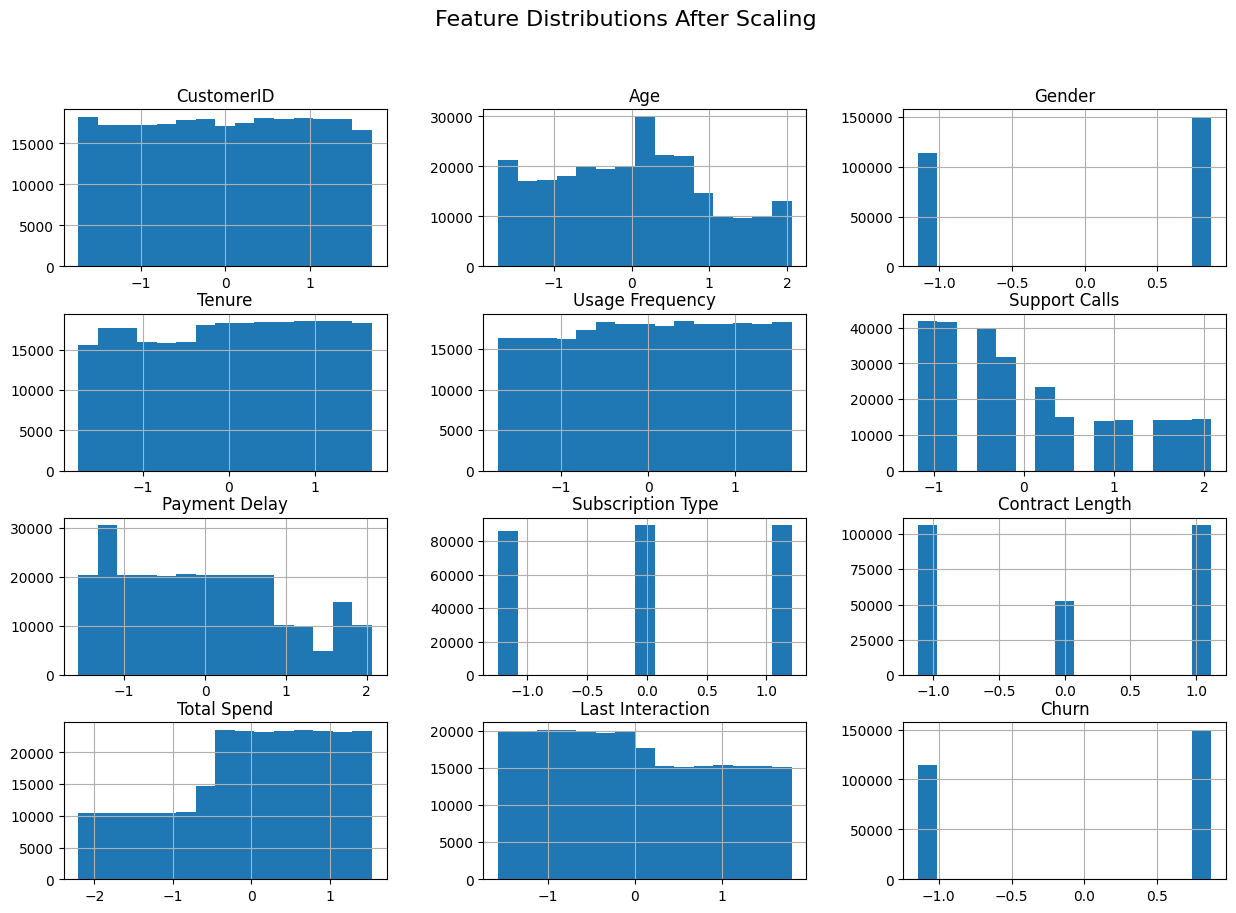

In [263]:
hist = X_train.hist(bins=15, figsize=(15, 10))
plt.suptitle("Feature Distributions After Scaling", fontsize=16)    
plt.show()

In [264]:
y_test.head()

0    1
1    1
2    1
3    1
4    0
Name: Churn, dtype: int64

In [265]:
y_test.unique()

array([1, 0])

In [267]:
X_train['Churn'].value_counts()

Churn
 0.874005    149952
-1.144158    114546
Name: count, dtype: int64